# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
Actualmente la columna `edad` es *float64* pero deberia ser *int64*.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype("int64")

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — Rango amplio (18 a 75 años), con media de 38.3 y mediana de 38 muy cercanas → distribución bastante simétrica, sin señales fuertes de sesgo.
- `nivel_ingreso` — Media (30,020) y mediana (30,024) casi idénticas, pero el máximo (74,791) está bastante por encima de percentil 75 (36,768) → posible cola derecha con algunos ingresos altos atípicos.
- `visitas_mes` — Máximo de 25 visitas frente a una media de 10 y std de 3.16 (eso son ~4.7 desviaciones estándar) → probablemente hay outliers de usuarios "hiperactivos".
- `compras_mes` — El percentil 25 es 0 → al menos una cuarta parte de los clientes no compró nada en el mes, variable claramente sesgada a la derecha.
- `gasto_publicidad_dirigida` — Mínimo en 0 y máximo en 75.51 con std de 10.88 → dispersión considerable, vale la pena revisar si el 0 significa "sin publicidad dirigida" o dato faltante codificado.
- `satisfaccion` — Rango 1–5 con std pequeño (0.685) → parece una escala tipo Likert, y la mayoría se concentra entre 3 y 4 (percentil 25 y 75).
- `ingreso_anual` — Std (34.48) casi igual a la media (36.59) → altísima variabilidad relativa, y el máximo (244.69) está muy alejado del percentil 75 (58.22), fuerte candidato a outliers o distribución muy sesgada.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(df["miembro_premium"].value_counts())
print("")
print(df["abandono"].value_counts())

0    12911
1     2089
Name: miembro_premium, dtype: int64

0    12739
1     2261
Name: abandono, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — Media de 0.139 → es una variable binaria (0/1), y solo ~13.9% de los clientes son premium.
- `abandono` — Media de 0.151 → también binaria, con una tasa de abandono (churn) del 15.07%.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
print("tipo_dispositivo =", df["tipo_dispositivo"].nunique())
print("")
print("region =", df["region"].nunique())

tipo_dispositivo = 3

region = 4


In [9]:
# Explorar variables categóricas y cómo se distribuyen
print(df["tipo_dispositivo"].value_counts())
print("")
print(df["region"].value_counts())

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  

Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas


- `tipo_dispositivo` — "móvil" domina claramente con 9,818 registros (~65% del total), más del doble que "escritorio" (3,720) y casi 7 veces "tablet" (1,462) → fuerte desbalance hacia el uso móvil, algo a considerar si vas a segmentar o modelar por este canal.
- `region` — Distribución más equilibrada entre las 4 categorías, aunque "norte" lidera con 4,395 y "este" queda más rezagada con 3,069 → diferencia de ~1,300 registros entre la región más y menos representada, sin un desbalance tan marcado como en tipo_dispositivo.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

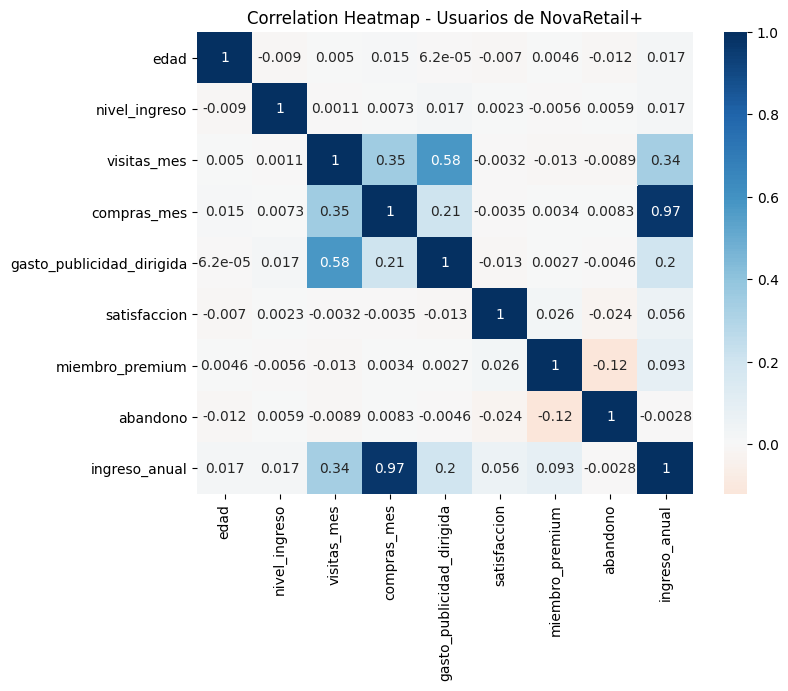

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Correlation Heatmap - Usuarios de NovaRetail+")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   

Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa que la gran mayoría de las correlaciones entre variables son muy bajas (cercanas a 0), lo que indica que la mayoría de las variables numéricas son prácticamente independientes entre sí.
- Las únicas relaciones que resaltan son `compras_mes` con `ingreso_anual` (0.97) y `visitas_mes` con `gasto_publicidad_dirigida`a (0.58), además de `visitas_mes` con `compras_mes` (0.35).


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación extremadamente alta con `compras_mes` (0.97), casi una relación lineal perfecta → probablemente `ingreso_anual` está construido a partir de compras_mes (o viceversa), lo cual habría que confirmar para evitar redundancia/multicolinealidad en un modelo. Le sigue `visitas_mes` con 0.34, bastante más moderada. Y con una relacion debil sigue `gasto_publicidad_dirigida` con 0.2.
- Con el resto de variables (`edad`, `nivel_ingreso`, `satisfaccion`) las correlaciones son prácticamente nulas (todas por debajo de 0.1 en valor absoluto).



### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

No es necesario generar un scatterplot **general** debido a que la mayoria de correlaciones son casi nulas. Con 9 variables numéricas, una matriz de dispersión generaría 36 gráficos individuales, la mayoría de los cuales mostrarían nubes de puntos sin ningún patrón (ruido visual), ya que sus correlaciones están entre -0.02 y 0.02 aproximadamente. Es más eficiente, desde el punto de vista analítico, ser selectivo: generar scatterplots únicamente para los pares que el heatmap señaló como relevantes.

### Scatterplot para pares clave

<AxesSubplot:xlabel='ingreso_anual', ylabel='compras_mes'>

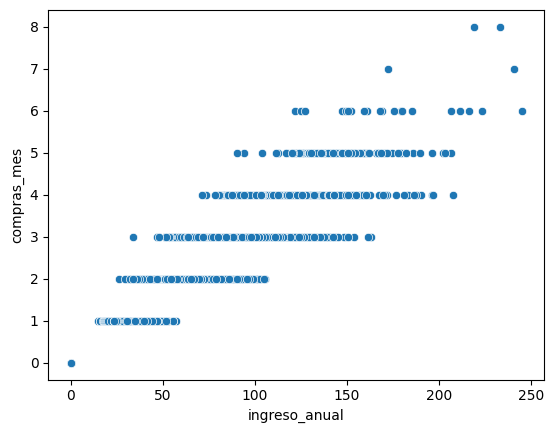

In [11]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x="ingreso_anual", y="compras_mes")

<AxesSubplot:xlabel='ingreso_anual', ylabel='visitas_mes'>

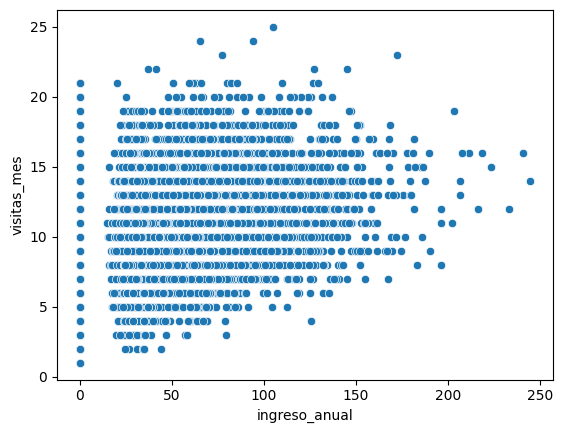

In [12]:
sns.scatterplot(data=df, x="ingreso_anual", y="visitas_mes")

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**`ingreso_anual` vs `compras_mes`**
- Dirección positiva y muy marcada — a mayor ingreso_anual, mayor compras_mes, de forma consistente en todo el rango.
- Dispersión baja. Los puntos se agrupan en bandas horizontales muy definidas (por cada valor entero de compras_mes hay un rango estrecho de ingreso_anual), lo que confirma visualmente la correlación de 0.97 observada en el heatmap.
- Prácticamente no hay Outliers — el único punto algo aislado es el de compras_mes = 0 con ingreso_anual = 0, pero no rompe el patrón general.
- Colinealidad alta. El patrón escalonado y casi perfectamente ordenado sugiere que ingreso_anual podría estar calculado directamente a partir de compras_mes (o de una variable muy cercana a ella), reforzando la sospecha de redundancia entre ambas.

**`ingreso_anual` vs `visitas_mes`**
- Dirección positiva, pero mucho más débil y menos definida que en el caso anterior.
- Dispersión alta. Para un mismo valor de ingreso_anual hay una amplia variedad de visitas_mes (por ejemplo, con ingreso_anual cercano a 0 se ven desde 1 hasta 21 visitas), y viceversa.
- Se observan algunos puntos algo alejados de la nube principal, como visitas altas (23-25) en ingresos bajos-medios (~70-170), o ingresos altos (~240) con pocas visitas (~14-16); no son extremos, pero rompen la tendencia central.
- Colinealidad baja. La nube de puntos dispersa es consistente con la correlación moderada (0.34) del heatmap — no hay indicio de que una variable dependa directamente de la otra.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [13]:
# Calcular correlación entre variables relevantes
df['ingreso_anual'].corr(df['compras_mes'], method='pearson')


0.9671485435708566

In [14]:
# Calcular correlación entre variables relevantes
df['ingreso_anual'].corr(df['visitas_mes'], method='pearson')

0.33714664324987453

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**`ingreso_anual` vs `compras_mes`**
- Correlación = 0.9671
- Dirección positiva.
- Magnitud muy fuerte, casi perfecta (cercana a 1) — de las correlaciones más altas posibles entre dos variables distintas.
- Colinealidad alta. Un coeficiente tan cercano a 1 sugiere que ingreso_anual podría estar derivado matemáticamente de compras_mes (o ambas de una tercera variable común), más que representar dos fenómenos independientes. Esto es importante señalarlo porque, si se usaran ambas variables juntas en un modelo predictivo, generarían multicolinealidad.

**`ingreso_anual` vs `visitas_mes`**
- Correlación = 0.3371
- Dirección positiva.
- Magnitud débil a moderada — existe cierta tendencia, pero está lejos de ser una relación fuerte o determinante.
- Colinealidad: baja. No hay evidencia de dependencia directa entre ambas variables; su relación es más bien tenue y consistente con dos variables que comparten cierta influencia (a mayor ingreso, algo más de actividad) pero que no se explican mutuamente.

### Punto-biserial

In [15]:
# Calcular correlación entre variables relevantes
print("ingreso_anual y miembro_premium", pointbiserialr( df["ingreso_anual"], df["miembro_premium"] ))
print("")
print("ingreso_anual y abandono", pointbiserialr( df["ingreso_anual"], df["abandono"] ))

ingreso_anual y miembro_premium SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

ingreso_anual y abandono SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**`ingreso_anual` vs `miembro_premium`**
- Relación (statistic = 0.0931)
- Dirección positiva — ser miembro premium se asocia levemente con un mayor ingreso_anual.
- Magnitud baja. Un coeficiente de 0.093 indica una relación casi nula en términos prácticos, aunque la significancia estadística (posible por el tamaño de muestra, 15,000 registros) confirma que la asociación es real, solo que débil.

**`ingreso_anual` vs `abandono`**
- Relación prácticamente nula (statistic = -0.0028)
- Dirección negativa, pero tan cercana a cero que no es interpretable de forma confiable.
- Magnitud nula/despreciable. El ingreso_anual no parece influir en si un cliente abandona o no, al menos no de forma lineal.

### V de Cramér

In [16]:
# Función para calcular V de Cramér
tabla = pd.crosstab(df["tipo_dispositivo"], df["region"])
chi2, p, dof, expected = chi2_contingency(tabla)

In [17]:
# Aplicar V de Cramér en variables relevantes
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
print(cramers_v)

0.012378338407739397


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér

**`tipo_dispositivo` vs `region`**
- Relación V de Cramér = 0.0124
- Asociación prácticamente inexistente entre ambas variables categóricas.
- Sentido de negocio: también tiene lógica. Hoy en día, alguien en cualquier región puede tener un **`móvil, escritorio o tablet`** — el acceso a dispositivos no está tan ligado a la ubicación geográfica como podría estarlo, por ejemplo, el *ingreso o el tipo de producto comprado*.
- El uso de dispositivos **`(móvil, escritorio, tablet)`** suele estar más ligado a *hábitos personales, generación/edad, o contexto de uso* que a la ubicación geográfica del cliente.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — **`compras_mes`** genera directamente el **`ingreso_anual`**, no es solo correlación.

**Evidencia visual:**
- El scatterplot muestra bandas horizontales muy definidas y consistentes: para cada valor entero de **`compras_mes`** existe un rango estrecho de **`ingreso_anual`**, sin dispersión relevante.

**Evidencia numérica:** 
- Correlación de Pearson r = 0.9671 (heatmap y cálculo puntual coinciden).

**Interpretación**  
- A diferencia de una correlación estadística "casual" entre variables independientes, aquí existe una relación causal directa y por definición de negocio: el **`ingreso_anual`** representa el revenue que el cliente genera para la empresa, y ese revenue se produce precisamente a partir de las compras que realiza (**`ingreso_anual`** ≈ **`compras_mes`** × ticket promedio). La dirección de causalidad es clara y unidireccional (comprar → genera revenue), no al revés. El hecho de que r no sea exactamente 1.0 sugiere que el valor por compra (ticket promedio) varía entre clientes o transacciones, introduciendo algo de dispersión.

**No podemos afirmar**  
- Que todas las compras generan el mismo ticket promedio (no sabemos si hay variación en el valor por compra), ni que aumentar artificialmente las visitas o interacciones incrementará el revenue si no se traduce en más compras. 

**Implicación de negocio**  
- El número de compras mensuales es, por construcción, el principal impulsor directo del revenue por cliente. Cualquier estrategia para incrementar **`ingreso_anual`** debe enfocarse en aumentar la frecuencia de compra (ej. promociones de recompra, programas de fidelización), ya que es la variable con relación causal más clara y fuerte con el resultado económico. Además, dado que la relación es casi determinística, **`compras_mes`** podría usarse como proxy confiable del revenue en análisis donde **`ingreso_anual`** no esté disponible de inmediato.

### Hallazgo 2 — **`visitas_mes`** tiene una relación positiva pero débil con **`ingreso_anual`**

**Evidencia visual:** 
- El scatterplot muestra una nube de puntos con alta dispersión: para un mismo nivel de **`ingreso_anual`** (incluso cercano a 0) se observan clientes con entre 1 y 21+ visitas, y viceversa. No hay bandas definidas como en el caso de *compras_mes*.

**Evidencia numérica:**
- Correlación de Pearson r = 0.3371.

**Interpretación**  
- A diferencia de *compras_mes*, aquí sí se trata de una correlación moderada-débil, no una relación causal directa/definicional. Tiene sentido de negocio: visitar más la app o el sitio aumenta la oportunidad de comprar (y por tanto de generar revenue), pero visitar no garantiza comprar — de ahí que la relación sea bastante más débil que con *compras_mes* (0.34 vs 0.97). Las visitas son un paso previo en el embudo, no el evento que genera el ingreso en sí.

**No podemos afirmar**  
- Que aumentar las visitas de un cliente (ej. mediante notificaciones o campañas) vaya a traducirse proporcionalmente en más **`ingreso_anual`**, ya que la conversión de visita a compra depende de otros factores.
- Tampoco podemos afirmar causalidad en ninguna dirección con esta sola evidencia.

**Implicación de negocio**  
- Las visitas son un indicador de engagement, pero no un predictor fuerte de **`ingreso_anual`** por sí solas. Para NovaRetail+, esto sugiere que las estrategias enfocadas solo en aumentar tráfico (visitas) tendrán un impacto limitado en el ingreso si no van acompañadas de tácticas que mejoren la tasa de conversión (de visita a compra) — por ejemplo, mejoras en el checkout, recomendaciones personalizadas o promociones dirigidas a visitantes recurrentes que aún no compran.


### Hallazgo 3 — El **`tipo_dispositivo`** no depende de la **`region`** geográfica

**Evidencia visual:**   
- *(No aplica; se resume en la tabla de contingencia)*

**Evidencia numérica:** 
- V de Cramér = 0.0124

**Interpretación**  
El **`tipo_dispositivo`** *(móvil, escritorio o tablet)* es prácticamente independiente de la **`region`** *(norte, sur, oeste o este)* del cliente.

**No podemos afirmar**  
- Causalidad en ninguna dirección.

**Implicación de negocio**
- Las estrategias de optimización o uso de dispositiovs pueden aplicarse uniformemente en las 4 regiones, sin necesidad de personalizar por ubicación geográfica.

## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### **Limitaciones**
**Correlación ≠ causalidad**
- La mayoría de las relaciones exploradas (visitas, publicidad dirigida, membresía premium, satisfacción) son correlacionales, no causales. La única excepción es `compras_mes` → `ingreso_anual`, donde la relación es causal por definición de negocio (el revenue se genera a partir de las compras); en todos los demás casos, no podemos afirmar que una variable provoque cambios en otra.

**Variables externas no consideradas**
- No sabemos si hay factores fuera del dataset que expliquen simultáneamente varias relaciones observadas. Por ejemplo, la asociación entre `miembro_premium` y menor `abandono`/mayor `ingreso_anual` podría estar explicada por un tercer factor (ej. antigüedad del cliente, o nivel de compromiso previo) que hace que un cliente tanto se vuelva premium como compre más — sin que una cause la otra directamente.

**Posible causalidad inversa**
- No podemos descartar que la causalidad vaya en sentido contrario: clientes que ya compran más y son más leales podrían ser los que optan por hacerse `miembro_premium`, en vez de que ser `miembro_premium` los vuelva más leales.

### **Próximos pasos** 

**Probar segmentación adicional**
- Analizar la relación `ingreso_anual` vs `abandono` segmentando por rangos de `ingreso_anual` (bajo/medio/alto), para descartar relaciones no lineales ocultas por el coeficiente global.
- Cruzar `satisfaccion` con `miembro_premium` y `abandono` juntos, para ver si la satisfacción es el factor que realmente explica la menor tasa de abandono en clientes premium (mediación).

**Diseñar un experimento controlado (A/B test)**
- Ofrecer membresía premium gratuita por tiempo limitado a un grupo aleatorio de clientes no premium, y comparar su tasa de abandono y `ingreso_anual` posterior contra un grupo de control — esto sí permitiría hablar de causalidad entre `miembro_premium` y retención/revenue.
- Probar un incremento controlado de `gasto_publicidad_dirigida` en un grupo aleatorio de clientes y medir el efecto real sobre `visitas_mes` y `compras_mes` posteriores.

**Recolectar variables adicionales**
- Antigüedad del cliente (tenure), para distinguir entre clientes nuevos y recurrentes.
- Ticket promedio por compra, para descomponer con precisión la fórmula `ingreso_anual` ≈ `compras_mes` × ticket promedio.
- Datos temporales (por mes/trimestre), para poder analizar tendencias y no solo una fotografía estática.